imports

In [11]:
%load_ext autoreload
%autoreload 2

import warnings
import pandas as pd
import numpy as np
import plotly.express as px
from gencost.crosswalk import Crosswalk
from gencost.waterfall import DataBySubplant
import seaborn as sns
from matplotlib import pyplot as plt

warnings.simplefilter(action="once")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
pd.set_option('display.max_columns',None)

setup data source objects

In [2]:
xwalk = Crosswalk()
# self to be able to copy / paste from waterfall.py for dev ease
self = DataBySubplant(xwalk)

create final merged data output

In [8]:
df = self.merge_all(clean=True)

create data viz to check a sense for checks that make sense

In [12]:
df

,plant_id_eia,pf_subplant_id,subplant_id,report_date,step,capacity_mw,camd_capacity_mw,net_generation_mwh,generator_starts,fuel_starts,gross_generation_mwh,heat_in_mmbtu,associated_combined_heat_power,duct_burners,bypass_heat_recovery,solid_fuel_gasification,carbon_capture,fluidized_bed_tech,pulverized_coal_tech,stoker_tech,other_combustion_tech,subcritical_tech,supercritical_tech,ultrasupercritical_tech,age_from_report_year,avg_age_from_report_year,current_avg_age,age_of_observation,age_relative_to_avg,pollution_control_costs_per_kw,biofuel_mmbtu,coal_mmbtu,natural_gas_mmbtu,other_mmbtu,other_gas_mmbtu,petroleum_mmbtu,petroleum_coke_mmbtu,biofuel_net_mwh,coal_net_mwh,natural_gas_net_mwh,other_net_mwh,other_gas_net_mwh,petroleum_net_mwh,petroleum_coke_net_mwh,co2_tons,biofuel_gross_mwh,coal_gross_mwh,natural_gas_gross_mwh,other_gross_mwh,other_gas_gross_mwh,petroleum_gross_mwh,petroleum_coke_gross_mwh,nuclear_mmbtu,renew_mmbtu,waste_heat_mmbtu,nuclear_net_mwh,renew_net_mwh,waste_heat_net_mwh,nuclear_gross_mwh,renew_gross_mwh,waste_heat_gross_mwh,prime_mover,subplant_id_dup,inflator_to_2021,wage_scale,real_capex,real_opex,capex,opex,arc,net_cf,gross_cf,gross_hr,parasitic_load_pct,n_fuel_groups,top_fuel_share,top_fuel,fuel_category,report_year
0,3,0,0,2009-01-01,1,153.1,145.0,221908.0,44,44,243753.0,2.279918e+06,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,54.915811,57.414847,67.830253,12.914442,10.415407,2.92732,NaN,2274508.824,7.626193e+03,NaN,NaN,NaN,NaN,NaN,221185.839306,7.221607e+02,NaN,NaN,NaN,NaN,233919.995,NaN,242959.748582,7.932514e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST,0,1.206370,0.97293,1.014887e+08,6.691065e+06,8.412731e+07,5.546445e+06,113349.938389,0.165460,0.181748,9.353393,0.016288,0,0.996746,coal,coal,2009
1,3,0,0,2010-01-01,1,153.1,145.0,435334.0,14,14,469201.0,4.446264e+06,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,55.915127,57.414847,67.830253,11.915127,10.415407,2.92732,NaN,4481349.054,4.298291e+04,NaN,NaN,NaN,NaN,NaN,431305.637372,4.028363e+03,NaN,NaN,NaN,NaN,456186.432,NaN,464859.249129,4.341751e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST,0,1.186902,0.941299,1.307305e+08,7.263555e+06,1.101444e+08,6.119762e+06,108919.479614,0.324596,0.349848,9.476245,0.025252,0,0.990747,coal,coal,2010
2,3,0,0,2011-01-01,1,153.1,145.0,312130.0,9,9,344631.0,3.052056e+06,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,56.914442,57.414847,67.830253,10.915811,10.415407,2.92732,NaN,3154609.900,4.107051e+05,NaN,NaN,NaN,NaN,NaN,277011.308276,3.511869e+04,NaN,NaN,NaN,NaN,313140.535,NaN,305855.522322,3.877548e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST,0,1.150583,0.973222,1.290909e+08,7.519007e+06,1.121960e+08,6.534954e+06,99273.868365,0.232732,0.256966,8.856011,0.024234,0,0.887487,coal,≥60% coal,2011
3,3,0,0,2012-01-01,1,153.1,145.0,152102.0,6,6,168753.0,1.331234e+06,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,57.913758,57.414847,67.830253,9.916496,10.415407,2.92732,NaN,1428309.068,3.148310e+05,NaN,NaN,NaN,NaN,NaN,125223.885815,2.687811e+04,NaN,NaN,NaN,NaN,136584.417,NaN,138932.469021,2.982053e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST,0,1.127255,0.983656,1.268613e+08,5.645279e+06,1.125400e+08,5.007987e+06,92809.137000,0.113101,0.125483,7.888652,0.012381,0,0.823289,coal,≥60% coal,2012
4,3,0,0,2013-01-01,1,153.1,139.0,30627.0,2,2,37145.0,3.619710e+05,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,58.915811,57.414847,67.830253,8.914442,10.415407,2.92732,NaN,344887.718,3.609992e+04,NaN,NaN,NaN,NaN,NaN,27794.063253,2.832937e+03,NaN,NaN,NaN,NaN,37138.214,NaN,33709.161183,3.435839e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST,0,1.110982,0.951011,1.253700e+08,5.542604e+06,1.128461e+08,4.988924e+06,88892.152869,0.022836,0.027696,9.744812,0.00486,0,0.907502,coal,coal,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

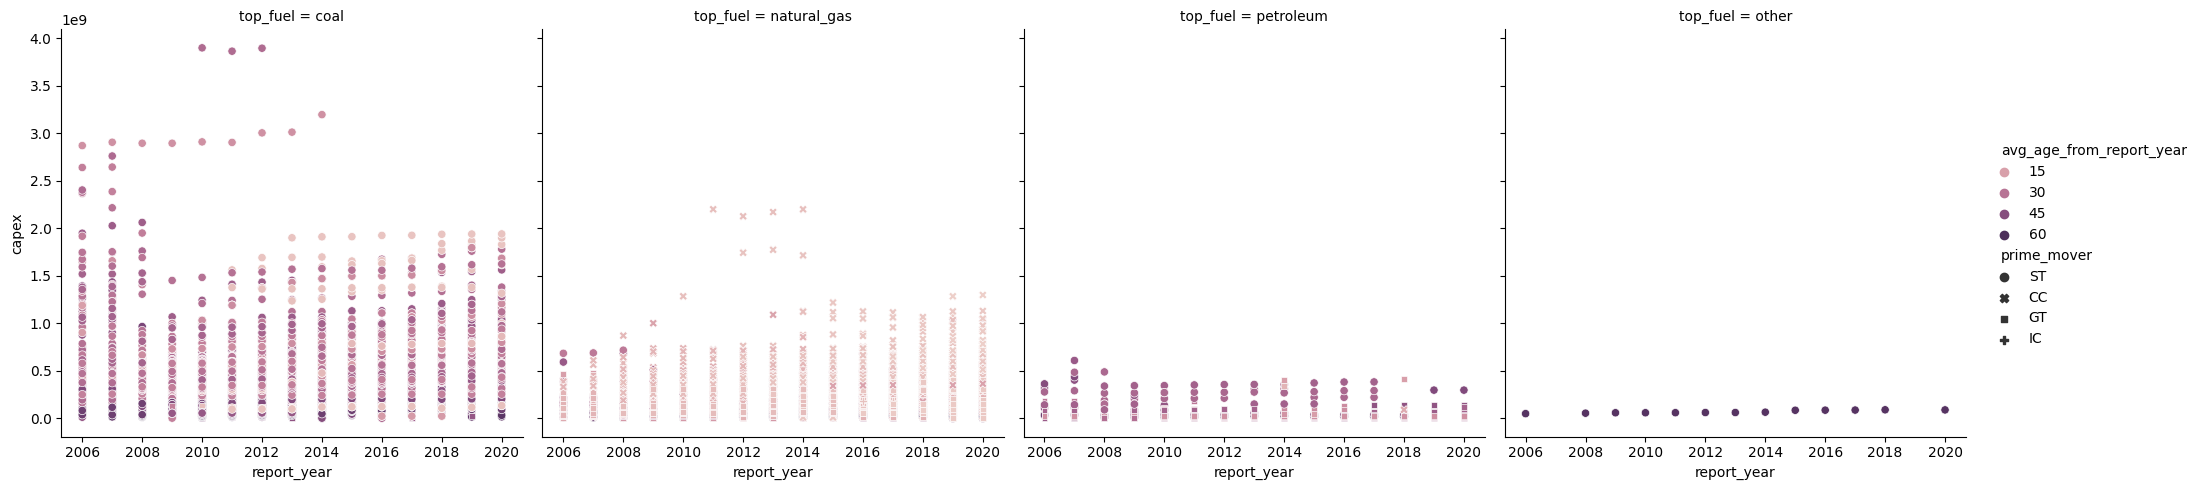

In [15]:
sns.relplot(
    data=df, x="report_year", y="capex",
    col="top_fuel", hue="avg_age_from_report_year", style="prime_mover",
    kind="scatter"
)

In [25]:
fig = px.scatter(df, x="report_year", y="opex", color="capacity_mw", facet_col="top_fuel",color_continuous_scale=px.colors.diverging.BrBG,title='opex by fuel and capacity')
fig.show()

In [21]:
fig_1 = px.scatter(df, x="report_year", y="opex", color="avg_age_from_report_year", facet_col="top_fuel",facet_row="prime_mover")
fig_1.show()